# Домашнее задание 3

### ИАД. 2025-2026

### Прогнозирование временных рядов

Мы постарались составить домашнее задание так, чтобы оно помогло закрепить все то, что мы прошли на лекциях и семинарах. Вы вольны использовать любые библиотеки, которые вам нравятся. Главное — это осознанность в выборе методов и интерпретации выводов.

В рамках домашнего задания будем работать с датасетом `NN5`, который можно скачать [здесь](https://zenodo.org/records/4656117). Временные ряды в этом датасете представляют собой данные по ежедневным снятиям наличных в банкоматах в Великобритании.

### Задание 1. Первичный анализ данных (1 балл)

In [1]:
# %pip install statsforecast==2.0.3

In [2]:
import logging

logger = logging.getLogger(__name__)
import sys

c_handler = logging.StreamHandler(sys.stdout)
logger.addHandler(c_handler)
logging.basicConfig(level=logging.INFO, force=True)

import random
import warnings
from datetime import datetime
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from statsforecast import StatsForecast, models
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

/home/xarm86/hse/iad-applied/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def mase(
    forecast: np.ndarray,
    insample: np.ndarray,
    outsample: np.ndarray,
    frequency: int,
) -> np.ndarray:
    """MASE loss as defined in "Scaled Errors" https://robjhyndman.com/papers/mase.pdf

    Args:
        forecast: Forecast values. Shape: batch, time_o
        insample: Insample values. Shape: batch, time_i
        outsample: Target values. Shape: batch, time_o
        frequency: Frequency value
    Returns:
        Same shape array with error calculated for each time step
    """
    return np.mean(np.abs(forecast - outsample)) / np.mean(
        np.abs(insample[:-frequency] - insample[frequency:])
    )

Нам пригодятся уже знакомые функции с семинаров по чтению рядов в формате tsf. Напомню, что иногда временные ряды могут быть представлены в tsf формате. Это такая структура данных, которая позволяет хранить метаинформацию о временных рядах, а также пары "первая дата — все значения временного ряда".

Функции позволяют считать данные в tsf формате и перевести их в формат, которым мы можем пользоваться.

In [4]:
def convert_tsf_to_dataframe(
    full_file_path_and_name: str,
    replace_missing_vals_with: Any = "NaN",
    value_column_name: str = "series_value",
) -> tuple[pd.DataFrame, str, int, str, str]:
    """
    Конвертирует файл формата TSF в pandas DataFrame.

    Args:
        full_file_path_and_name: Путь к файлу формата TSF.
        replace_missing_vals_with: Значение для замены пропусков.
        value_column_name: Имя столбца для значений временных рядов.

    Returns:
        DataFrame с данными временных рядов.
        Частота данных.
        Прогнозируемый горизонт.
        Содержат ли данные пропуски.
        Равны ли длины временных рядов.

    """
    col_names = []
    col_types = []
    all_data = {}
    all_series = []
    frequency = None
    forecast_horizon = None
    contain_missing_values = None
    contain_equal_length = None
    data_started = False

    with open(full_file_path_and_name, "r", encoding="cp1252") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            if line.startswith("@"):
                if line.startswith("@data"):
                    data_started = True
                    # Инициализируем словарь для данных атрибутов
                    for col in col_names:
                        all_data[col] = []
                else:
                    parts = line.split(" ")
                    if line.startswith("@attribute"):
                        col_names.append(parts[1])
                        col_types.append(parts[2])
                    elif line.startswith("@frequency"):
                        frequency = parts[1]
                    elif line.startswith("@horizon"):
                        forecast_horizon = int(parts[1])
                    elif line.startswith("@missing"):
                        contain_missing_values = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
                    elif line.startswith("@equallength"):
                        contain_equal_length = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
            elif not line.startswith("#") and data_started:
                parts = line.split(":")
                # Последняя часть содержит значения ряда
                series_vals = parts[-1].split(",")
                numeric_series = [
                    replace_missing_vals_with if val == "?" else float(val) for val in series_vals
                ]
                all_series.append(pd.Series(numeric_series).array)
                # Преобразуем и сохраняем значения атрибутов
                for i in range(len(col_names)):
                    if col_types[i] == "numeric":
                        all_data[col_names[i]].append(int(parts[i]))
                    elif col_types[i] == "string":
                        all_data[col_names[i]].append(parts[i])
                    elif col_types[i] == "date":
                        all_data[col_names[i]].append(
                            datetime.strptime(parts[i], "%Y-%m-%d %H-%M-%S")
                        )

    all_data[value_column_name] = all_series
    loaded_data = pd.DataFrame(all_data)
    return loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length


def date_to_daterange(x: pd.Series, freq: str) -> pd.Series:
    """
    Преобразует временные метки в диапазон дат.

    Args:
        x: Временные метки.
        freq: Частота.

    Returns:
        pd.Series с диапазоном дат.

    """
    return pd.Series(pd.date_range(start=x.iloc[0], periods=len(x), freq=freq))


def convert_tsf_to_multivariate_or_standard_format(
    tsf_data_path: str,
    target_column: str = "series_value",
    date_from_column: str = "start_timestamp",
    id_column: str = "series_name",
    # one from ["multivariate", "standard"]
    format: str = "multivariate",
) -> pd.DataFrame:
    """
    Преобразует данные формата TSF в формат pandas DataFrame:
        если format == "standard" -> датафрейм с колонками "id", "date" и "value"
        если format == "multivariate" -> pivot таблица c date в качестве индекса,
            id в качестве колонок и значениями из value_column_name

    Args:
        tsf_data_path: Путь к файлу формата TSF.
        target_column: Имя столбца с целевой переменной.
        date_from_column: Имя столбца с переменной дат.
        id_column: Имя столбца с идентификаторами временных рядов.
        format: Формат данных ("multivariate" или "standard").

    Returns:
        pd.DataFrame с данными в формате "id", "date" и "value".

    """
    FREQ_MAP = {
        "monthly": "MS",
        "10_minutes": "10min",
        "half_hourly": "30min",
        "minutely": "1min",
        "daily": "D",
        "weekly": "7D",
        "yearly": "YS",
        "quarterly": "QS",
        "hourly": "H",
    }

    tsf_df, freq = convert_tsf_to_dataframe(tsf_data_path)[:2]

    # Преобразуем списки в {target_column} в "длинный столбец" со значениями
    tsf_df = tsf_df.explode(target_column)
    # Заменим повторяющиеся значения даты в {date_column} на date_range
    tsf_df["date"] = (
        tsf_df.groupby(id_column, sort=False)[date_from_column]
        .apply(lambda x: date_to_daterange(x, FREQ_MAP[freq]))
        .values
    )
    tsf_df = tsf_df.drop(columns=date_from_column)
    # Переименуем колонки
    tsf_df = tsf_df.rename(columns={id_column: "id", target_column: "value"}).reset_index(
        drop=True
    )
    # Приведем {id_column} к численным значениям
    ids2num = dict(zip(tsf_df["id"].unique(), np.arange(tsf_df["id"].nunique())))
    tsf_df["id"] = tsf_df["id"].map(ids2num)

    if format == "standard":
        return tsf_df
    return pd.pivot_table(tsf_df, values="value", index="date", columns="id")

#### Задание 1.1: Загрузка данных (0 баллов)

Давайте скачаем датасет __NN5__ и загрузим его, воспользовавшись функцией `convert_tsf_to_multivariate_or_standard_format`.

In [5]:
# !wget "https://zenodo.org/records/4656117/files/nn5_daily_dataset_without_missing_values.zip?download=1" -O nn5_daily_dataset_without_missing_values.zip
# !unzip -o nn5_daily_dataset_without_missing_values.zip
# !rm nn5_daily_dataset_without_missing_values.zip

In [6]:
df = convert_tsf_to_multivariate_or_standard_format(
    "nn5_daily_dataset_without_missing_values.tsf", format="standard"
)
df.head()

,id,value,date
0,0,13.407029,1996-03-18
1,0,14.725057,1996-03-19
2,0,20.564059,1996-03-20
3,0,34.70805,1996-03-21
4,0,26.629819,1996-03-22


#### Задание 1.2: Типы данных (0.3 балла)

Выведите типы данных в датасете. Проверьте, что они корректные: даты должны быть в формате datetime, id — object, а значения временных рядов — float. Если это не так, то исправьте их.

In [7]:
# --- Your code here ---
df.dtypes

id                int64
value            object
date     datetime64[ns]
dtype: object

In [8]:
df["date"] = pd.to_datetime(df["date"])
df["id"] = df["id"].astype(str)
df["value"] = pd.to_numeric(df["value"]).astype(float)
df.dtypes

id               object
value           float64
date     datetime64[ns]
dtype: object

#### Задание 1.3: Пропуски (0.05 балла)

Проверьте, есть ли в данных пропуски. Если они есть, то заполните их предыдущими значениями. Если пропусков нет, то просто выведите сообщение об этом.

In [9]:
# --- Your code here ---
df.isna().sum()

id       0
value    0
date     0
dtype: int64

In [10]:
# Визуальный анализ показал, что пропуски отсуТсТвуют 

#### Задание 1.4: Визуальный анализ временных рядов (0.4 балла)

Постройте линейные графики временных рядов. По оси X отложите время, по оси Y — значения временного ряда.

Используйте Plotly, чтобы можно было отложить сразу все временные ряды на одном графике.

In [11]:
# --- Your code here ---
import plotly.express as px

fig = px.line(
    df,
    x="date",
    y="value",
    color="id",
    title="ВР",
    labels={
        "date": "Дата",
        "value": "Значение",
        "id": "ID ВР"
    }
)

fig.show()

__Ответьте на следующие вопросы:__
- Какова частотность (frequency) данных?
- Выровнены ли временные ряды?
- Стационарны ли временные ряды? Если нет, то какие признаки нестационарности вы можете выделить?
- На какие группы можно разбить временные ряды по наличию общих признаков? Есть ли что-то, чем похожи все временные ряды?
- Есть ли в рядах выбросы? Как вы можете это определить?

In [12]:
# frequency

df = df.sort_values(["id", "date"]).reset_index(drop=True)

freq_info = (
    df.groupby("id")["date"]
    .apply(lambda x: x.sort_values().diff().dropna().mode().iloc[0])
)

freq_info.value_counts()

date
1 days    111
Name: count, dtype: int64

1. Частотность данных - 1 день.

In [13]:
alignment_info = df.groupby("id").agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    n_observations=("date", "count")
)

alignment_info.head()

,start_date,end_date,n_observations
id,,,
0,1996-03-18,1998-05-17,791
1,1996-03-18,1998-05-17,791
10,1996-03-18,1998-05-17,791
100,1996-03-18,1998-05-17,791
101,1996-03-18,1998-05-17,791


2. Ряды выровнены. 

In [14]:
# Расширенный тест Дики — Фуллера (ADF-тест) — 
# это популярный статистический метод, используемый 
# в эконометрике и анализе данных для проверки 
# временного ряда на стационарность.

from statsmodels.tsa.stattools import adfuller

stationarity_results = []

for series_id, group in df.groupby("id"):
    values = group.sort_values("date")["value"].dropna()

    adf_result = adfuller(values)
    p_value = adf_result[1]

    stationarity_results.append({
        "id": series_id,
        "adf_p_value": p_value,
        "is_stationary_5_percent": p_value < 0.05
    })

stationarity_df = pd.DataFrame(stationarity_results)

stationarity_df.head()

,id,adf_p_value,is_stationary_5_percent
0,0,0.421800,False
1,1,0.000060,True
2,10,0.000720,True
3,100,0.000252,True
4,101,0.000504,True


In [15]:
n_stationary = stationarity_df["is_stationary_5_percent"].sum()
n_total = len(stationarity_df)

print(f"Стационарных рядов: {n_stationary} из {n_total}")
print(f"Их доля: {n_stationary / n_total}")

Стационарных рядов: 98 из 111
Их доля: 0.8828828828828829


In [16]:
non_stationary_ids = stationarity_df.loc[
    stationarity_df["is_stationary_5_percent"] == False,
    "id"
]

df_non_stationary = df[df["id"].isin(non_stationary_ids)]

fig = px.line(
    df_non_stationary,
    x="date",
    y="value",
    color="id",
    title="ВР",
    labels={
        "date": "Дата",
        "value": "Значение",
        "id": "ID ВР"
    }
)

fig.show()

3. Большая часть рядов стационарна при уровне значимости 0.05. Однако есть некоторые нестационарные ряды. Как видно на графике, средние и дисперсии в них сильно меняются

In [17]:
features = df.groupby("id").agg(
    mean_value=("value", "mean"),
    std_value=("value", "std"),
    min_value=("value", "min"),
    max_value=("value", "max"),
    median_value=("value", "median")
)

features["range_value"] = features["max_value"] - features["min_value"]

features["level_group"] = pd.qcut(
    features["mean_value"],
    q=3,
    labels=["low", "middle", "high"]
)

features["volatility_group"] = pd.qcut(
    features["std_value"],
    q=3,
    labels=["low std", "middle std", "high std"]
)

features[["mean_value", "std_value", "range_value", "level_group", "volatility_group"]].head(20)

,mean_value,std_value,range_value,level_group,volatility_group
id,,,,,
0,28.544690,12.147350,75.949546,high,high std
1,17.498237,6.283581,46.641156,middle,low std
10,21.458410,9.214770,63.818027,high,high std
100,19.401752,7.106886,41.595805,middle,middle std
101,22.143405,11.019175,68.027211,high,high std
102,7.935645,3.322985,23.157596,low,low std
103,23.321205,12.036756,75.340136,high,high std
104,16.147045,6.508466,44.926304,low,middle std
105,19.418346,9.038417,53.897392,middle,high std


4. Уровень значений у всех рядов одинаковый, как будто бы заминмаксили его от 0 до 100 для каждого ВР. 

5. Про выборсы - не буду ничего из кода писать, просто напишу, что визуально они есть и проявляются как одиночные очень высокие столбцы. 

#### Задание 1.5: Выделение тестовой выборки (0.25 балла)

Выделите 10% данных для теста, а остальные 90% оставьте для обучения. Делайте это очень аккуратно, чтобы не нарушить временную и многомерную структуру данных!

Вспомните и напишите, в чем особенность выделения тестовой выборки в задаче прогнозирования временных рядов и в задаче прогнозирования __многомерных__ временных рядов.

Обратите внимание, что временные ряды выровнены, а значит, в отличие от семинара, пробегаться в цикле по каждому id не нужно. Подумайте, как можно сделать это более эффективно.

In [18]:
# --- Your code here ---
df = df.sort_values("date").reset_index(drop=True)
unique_dates = df["date"].sort_values().unique()

test_size = int(len(unique_dates) * 0.1)

train_dates = unique_dates[:-test_size]
test_dates = unique_dates[-test_size:]

train_df = df[df["date"].isin(train_dates)].copy()
test_df = df[df["date"].isin(test_dates)].copy()

print("Train:", train_df["date"].min(), "—", train_df["date"].max())
print("Test:", test_df["date"].min(), "—", test_df["date"].max())

print("Доля test:", len(test_df) / len(df))

# Id у нас строка - сортится плохо, поэтому сортим везде по датам, 
# наверочку сделал их уникальными, хотя вроде бы все выровнено и так
# Ну и разумеется, что нельзя прошлое предсказывать по будущему. 
# По идее можно было бы заиспользовать train_test_split без shuffle, 
# Но так нагляднее и надежнее.


Train: 1996-03-18 00:00:00 — 1998-02-27 00:00:00
Test: 1998-02-28 00:00:00 — 1998-05-17 00:00:00
Доля test: 0.09987357774968394


### Задание 2. Полный анализ одного временного ряда (4 балла)

#### Задание 2.1: Визуальный анализ (0.5 балла)

Выделите из данных временной ряд с номером 92. Постройте его линейный график.

In [19]:
# --- Your code here ---
series_92 = (
    df[df["id"] == "92"]
    .sort_values("date")
    .copy()
)

fig = px.line(
    series_92,
    x="date",
    y="value",
    title="Временной ряд 92",
    labels={
        "date": "Дата",
        "value": "Значение"
    }
)

fig.show()

Постройте графики автокорреляций (ACF) и частных автокорреляций (PACF) до 40-го лага для тренировочной выборки.

<Figure size 1200x500 with 0 Axes>

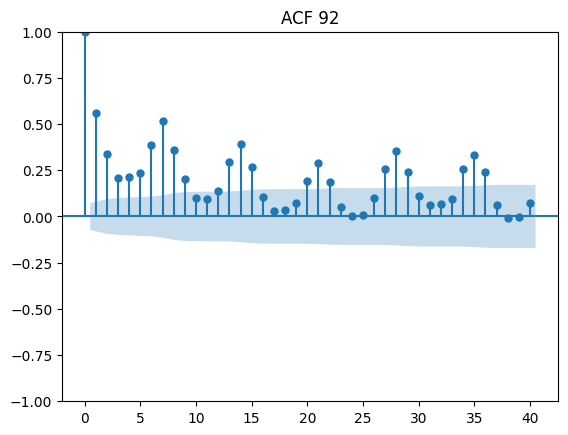

<Figure size 1200x500 with 0 Axes>

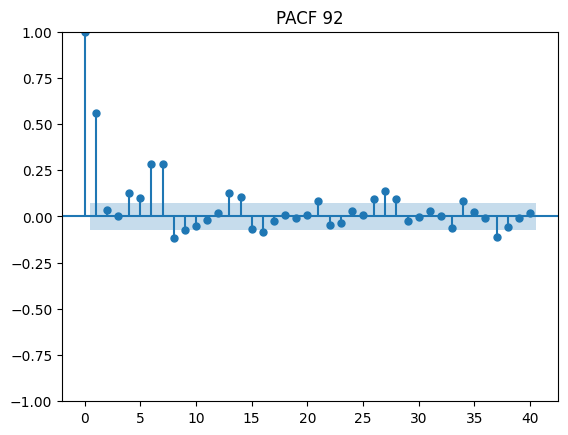

In [20]:
# --- Your code here ---
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

train_series_92 = (
    train_df[train_df["id"] == "92"]
    .sort_values("date")
    .copy()
)

values_92 = train_series_92["value"].dropna()


plt.figure(figsize=(12, 5))
plot_acf(values_92, lags=40)
plt.title("ACF 92")
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(values_92, lags=40, method="ywm")
plt.title("PACF 92")
plt.show()

__Ответьте на следующие вопросы:__
- Стационарен ли временной ряд?
- Присутствует ли в нём тренд? Сезонность? Цикличность?
- Если ряд сезонный, то какой период выглядит наиболее вероятным?

In [21]:
stationarity_df[stationarity_df["id"] == "92"] # Cтационарен...

,id,adf_p_value,is_stationary_5_percent
103,92,0.000877,True


In [22]:
series_92["rolling_mean_30"] = series_92["value"].rolling(window=30).mean()

fig = px.line(
    series_92,
    x="date",
    y=["value", "rolling_mean_30"],
    title="Ряд 92 и скользящее среднее 30 дней",
    labels={
        "date": "Дата",
        "value": "Значение"
    }
)

fig.show()

2. Тренд есть - скользящее среднее увеличивается. Сезонность тоже есть - видно по графикам ACF, так как пики наблюдаются раз в 7 дней. Цикличность тоже есть, видно по колебаниям скользящего среднего. Я смотрел на расстояние между минимальными экстремумами, оно везде разная.
3. Неделя (7 дней).

#### Задание 2.2: Построение модели SARIMA (2 балла)

Пользуясь правилами отсюда: https://people.duke.edu/~rnau/arimrule.htm, попробуйте подобрать параметры SARIMA модели, как мы делали это на семинаре.

Не забудьте о возможности использовать предобработку данных, например, логарифмирование и удаление выбросов (самое простое — это воспользоваться IQR: https://medium.com/@divyansh9144/iqr-interquartile-range-for-anomaly-detection-f9c568d1195f).

Если вы используете предобработку, то обязательно укажите, какую именно и почему.

In [23]:
# --- Your code here ---
series_id = "92"

train_92 = (
    train_df[train_df["id"].astype(str) == series_id]
    .sort_values("date")
    .copy()
)

test_92 = (
    test_df[test_df["id"].astype(str) == series_id]
    .sort_values("date")
    .copy()
)

y_train = train_92.set_index("date")["value"].asfreq("D")
y_test = test_92.set_index("date")["value"].asfreq("D")

In [24]:
# Делаем IQR предобработку данных 
# q1 = y_train.quantile(0.25)
# q3 = y_train.quantile(0.75)
# iqr = q3 - q1

# lower_bound = q1 - 1.5 * iqr
# upper_bound = q3 + 1.5 * iqr

# print(lower_bound, upper_bound)

y_train_processed = y_train

In [25]:
import itertools

seasonal_period = 7

p_values = [0, 1, 2, 3, 6]
q_values = [0, 1, 2, 3, 6]
d_values = [0, 1]

P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]

orders = list(itertools.product(p_values, d_values, q_values))
seasonal_orders = list(itertools.product(P_values, D_values, Q_values, [seasonal_period]))

results = []

for order in orders:
    for seasonal_order in seasonal_orders:
        model = SARIMAX(
            y_train_processed,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

        results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": fitted_model.aic
        })

sarima_results = pd.DataFrame(results).sort_values("aic").reset_index(drop=True)

sarima_results.head(10)

,order,seasonal_order,aic
0,"(2, 0, 6)","(0, 1, 1, 7)",4367.965013
1,"(1, 1, 6)","(1, 1, 1, 7)",4371.217478
2,"(1, 0, 6)","(0, 1, 1, 7)",4372.059421
3,"(0, 0, 6)","(1, 1, 1, 7)",4374.294470
4,"(2, 1, 6)","(1, 1, 1, 7)",4374.589565
5,"(1, 0, 6)","(1, 1, 1, 7)",4375.463624
6,"(3, 0, 6)","(0, 1, 1, 7)",4375.761559
7,"(6, 1, 6)","(1, 1, 1, 7)",4376.132021
8,"(3, 1, 6)","(1, 1, 1, 7)",4376.317423
9,"(6, 0, 0)","(1, 1, 1, 7)",4376.408355


In [26]:
best_order = sarima_results.loc[0, "order"]
best_seasonal_order = sarima_results.loc[0, "seasonal_order"]

print("Best params:")
print("order =", best_order)
print("seasonal_order =", best_seasonal_order)
print("AIC =", sarima_results.loc[0, "aic"])

Best params:
order = (2, 0, 6)
seasonal_order = (0, 1, 1, 7)
AIC = 4367.965013384047


In [27]:
best_model = SARIMAX(
    y_train_processed,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_model_fit = best_model.fit(disp=False)

print(best_model_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               value   No. Observations:                  712
Model:             SARIMAX(2, 0, 6)x(0, 1, [1], 7)   Log Likelihood               -2173.983
Date:                             Sun, 07 Jun 2026   AIC                           4367.965
Time:                                     18:28:42   BIC                           4413.346
Sample:                                 03-18-1996   HQIC                          4385.518
                                      - 02-27-1998                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.8185      0.065     27.912      0.000       1.691       1.946
ar.L2         -0.8672      

#### Задание 2.3: Анализ остатков (0.5 балла)

Постройте графики ACF и PACF остатков модели SARIMA. Проверьте, что в остатках нет значимых автокорреляций. Если они есть, то попробуйте объяснить, почему это происходит.

Проведите тест на стационарность остатков модели. Проведите тест на автокорреляцию остатков модели. Проинтерпретируйте результаты тестов. Если тесты показывают, что остатки нестационарны или в них есть автокорреляция, то попробуйте объяснить, почему это происходит.

In [28]:
# --- Your code here ---
residuals = best_model_fit.resid
residuals = residuals.dropna()

fig = px.line(
    residuals,
    title="Остатки SARIMA 92",
    labels={
        "index": "Дата",
        "value": "Остаток"
    }
)

fig.show()

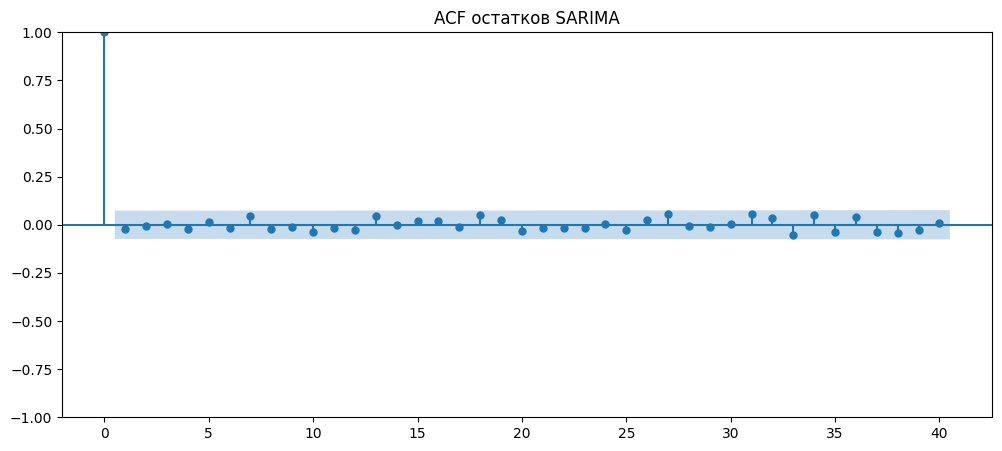

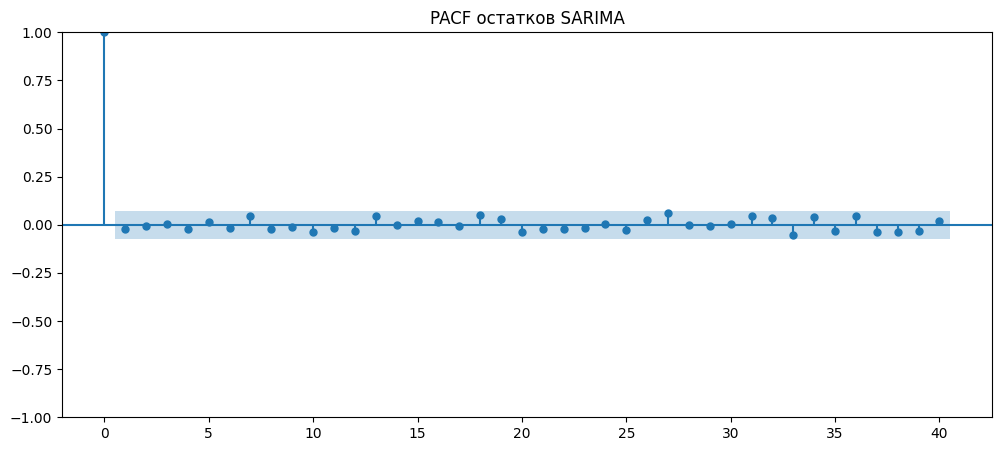

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(residuals, lags=40, ax=ax)
ax.set_title("ACF остатков SARIMA")
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
plot_pacf(residuals, lags=40, method="ywm", ax=ax)
ax.set_title("PACF остатков SARIMA")
plt.show()

In [30]:
adf_result = adfuller(residuals)

print("ADF:", adf_result[0])
print("p-value:", adf_result[1])

ADF: -27.339789441779224
p-value: 0.0


#### Задание 2.4: Получение прогнозов и выводы (1 балл)

С помощью полученной модели постройте прогноз на тестовую выборку.

Постройте график прогноза и фактических значений. Сделайте выводы о том, насколько хорошо модель предсказывает временной ряд.

Посчитайте метрику MASE, которую мы имплементировали в начале ноутбука. Объясните, что она показывает и почему ее потенциально полезнее использовать для сравнения моделей, чем MAE или MAPE. Выводы по самому значению метрики делать не нужно.

In [31]:
# --- Your code here ---
forecast_result = best_model_fit.get_forecast(steps=len(y_test))

forecast = forecast_result.predicted_mean
forecast.index = y_test.index

conf_int = forecast_result.conf_int()
conf_int.index = y_test.index

forecast.head()

date
1998-02-28    28.289531
1998-03-01    21.641383
1998-03-02    24.283325
1998-03-03    23.261362
1998-03-04    25.564888
Freq: D, Name: predicted_mean, dtype: float64

In [32]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_train.index[-120:],
    y=y_train.values[-120:],
    mode="lines",
    name="Train"
))

fig.add_trace(go.Scatter(
    x=y_test.index,
    y=y_test.values,
    mode="lines",
    name="Test"
))

fig.add_trace(go.Scatter(
    x=forecast.index,
    y=forecast.values,
    mode="lines",
    name="SARIMA forecast"
))

fig.update_layout(
    title="SARIMA прогноз 92",
    xaxis_title="Дата",
    yaxis_title="Значение"
)

fig.show()

In [33]:
comparison = pd.DataFrame({
    "actual": y_test,
    "forecast": forecast
}).dropna()

mase_value = mase(
    forecast=comparison["forecast"].values,
    insample=y_train.values,
    outsample=comparison["actual"].values,
    frequency=7
)

# MASE хорошо показывает, лучше ли наша модель нативного
# сезонного прогноза (значение должно быть меньше 1)

print("MASE:", mase_value)


MASE: 1.0298804526668517


### Задание 3. Построение бейзлайнов на всех рядах и автоматический подбор параметров (2 балла)

#### Задание 3.1: Запуск бейзлайнов (1 балл)
Давайте будем использовать statsforecast для бейзлайнов, так же как мы делали это на семинаре: https://nixtlaverse.nixtla.io/statsforecast/index.html

Постройте прогнозы на всех рядах с помощью следующих бейзлайнов:
- Naive
- Seasonal Naive
- AutoARIMA
- еще 2 на ваш выбор (например, ETS, Theta, TBATS или другие, которые вам нравятся). Кратко опишите суть выбранных моделей.

In [34]:
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    AutoARIMA,
    AutoETS,
    AutoTheta
)

# Переименуйте колонки, так как библиотека требует названия "unique_id", "y", "ds"
# --- Your code here ---

sf_train = train_df.rename(
    columns={
        "id": "unique_id",
        "date": "ds",
        "value": "y"
    }
).copy()

sf_test = test_df.rename(
    columns={
        "id": "unique_id",
        "date": "ds",
        "value": "y"
    }
).copy()

h = sf_test["ds"].nunique()

print("Горизонт прогноза:", h)
print("Период test:", sf_test["ds"].min(), "—", sf_test["ds"].max())

# Инициализируйте модели
# --- Your code here ---

season_length = 7

# models = [
#     Naive(), # Последнее известное повторяется 
#     SeasonalNaive(season_length=season_length), # Повторялся предыдущий сезон
#     AutoARIMA(season_length=season_length), # Сам подбирает для аримы
#     AutoETS(season_length=season_length), # Сам подбирает для ETS
#     AutoTheta(season_length=season_length) # Сам подбирает под Theta
# ]

models = [
    Naive(), # Последнее известное повторяется 
    SeasonalNaive(season_length=season_length), # Повторялся предыдущий сезон
    AutoARIMA(), # Сам подбирает для аримы
    AutoETS(), # Сам подбирает для ETS
    AutoTheta() # Сам подбирает под Theta
]

# Получите прогнозы
# --- Your code here ---

sf = StatsForecast(
    models=models,
    freq="D",
    n_jobs=-1
)

forecasts_df = sf.forecast(
    df=sf_train,
    h=h
)

print("Размер прогнозов:", forecasts_df.shape)
print("Количество рядов в прогнозах:", forecasts_df["unique_id"].nunique())
print("Количество дат прогноза:", forecasts_df["ds"].nunique())

forecasts_df.head()

Горизонт прогноза: 79
Период test: 1998-02-28 00:00:00 — 1998-05-17 00:00:00
Размер прогнозов: (8769, 7)
Количество рядов в прогнозах: 111
Количество дат прогноза: 79


,unique_id,ds,Naive,SeasonalNaive,AutoARIMA,AutoETS,AutoTheta
0,0,1998-02-28,45.493197,30.938209,33.807734,36.625346,38.828399
1,0,1998-03-01,45.493197,25.864512,25.867965,36.654342,38.849607
2,0,1998-03-02,45.493197,21.230159,24.891233,36.683339,38.870815
3,0,1998-03-03,45.493197,29.733560,30.264021,36.712335,38.892024
4,0,1998-03-04,45.493197,42.871315,44.231046,36.741331,38.913232


In [35]:
eval_df = sf_test.merge(
    forecasts_df,
    on=["unique_id", "ds"],
    how="left"
)

eval_df.head()

,unique_id,y,ds,Naive,SeasonalNaive,AutoARIMA,AutoETS,AutoTheta
0,4,17.389456,1998-02-28,34.906463,13.888889,20.446041,22.105220,24.953037
1,67,56.614940,1998-02-28,60.678590,44.213572,50.820780,47.456345,48.328742
2,82,23.908469,1998-02-28,50.157812,21.120463,28.714427,30.552811,33.479473
3,1,13.180272,1998-02-28,28.089569,14.129819,18.997300,17.833042,19.992186
4,109,17.913832,1998-02-28,35.246599,18.792517,26.226662,22.308158,22.274943


#### Задание 3.2: Анализ результатов (1 балл)

Постройте графики фактических значений и прогнозов для всех бейзлайнов для ряда 92. Выведите метрики MASE.

Что можно сказать о каждом из бейзлайнов? Какой из бейзлайнов лучше всего предсказывает временной ряд?

Смогли ли вы руками подобрать гиперпараметры для SARIMA модели лучше, чем автоматический подбор в библиотеке? Если да, то вы огромный молодец! Если нет, то не расстраивайтесь, так бывает.

In [36]:
# --- Your code here ---
series_id = "92"

eval_92 = (
    eval_df[eval_df["unique_id"].astype(str) == series_id]
    .sort_values("ds")
    .copy()
)

model_cols = [
    col for col in eval_92.columns
    if col not in ["unique_id", "ds", "y"]
]

plot_df = eval_92.melt(
    id_vars=["ds"],
    value_vars=["y"] + model_cols,
    var_name="model",
    value_name="value"
)

plot_df["model"] = plot_df["model"].replace({"y": "Actual"})

fig = px.line(
    plot_df,
    x="ds",
    y="value",
    color="model",
    title="Прогноз 92",
    labels={
        "ds": "Дата",
        "value": "Значение",
        "model": "Модель"
    }
)

fig.show()

In [37]:
season_length = 7

train_92_values = (
    sf_train[sf_train["unique_id"].astype(str) == series_id]
    .sort_values("ds")["y"]
    .values
)

test_92_values = eval_92["y"].values

metrics = []

for model_name in model_cols:
    forecast_values = eval_92[model_name].values

    metrics.append({
        "model": model_name,
        "MASE": mase(
            forecast=forecast_values,
            insample=train_92_values,
            outsample=test_92_values,
            frequency=season_length
        ),
    })

metrics_df = (
    pd.DataFrame(metrics)
    .sort_values("MASE")
    .reset_index(drop=True)
)

metrics_df

,model,MASE
0,SeasonalNaive,1.127296
1,AutoARIMA,1.630907
2,AutoETS,1.632661
3,AutoTheta,1.691124
4,Naive,3.246884


1. Лучший - SeasonalNaive
2. Для ARIMA получилось руками подобрать лучше. 

In [38]:
best_model_name = metrics_df.loc[0, "model"]
best_mase = metrics_df.loc[0, "MASE"]

print("Лучшая модель:", best_model_name)
print("Лучший MASE:", best_mase)

Лучшая модель: SeasonalNaive
Лучший MASE: 1.1272963460381045



Постройте датафрейм с MASE для всех бейзлайнов (агрегированный по всем рядам). Какой из бейзлайнов лучше всего предсказывает временные ряды в нашем датасете? Какой из бейзлайнов хуже всего предсказывает временные ряды в нашем датасете? Как вы думаете, почему так происходит?

In [39]:
# --- Your code here ---

model_cols = [
    col for col in eval_df.columns
    if col not in ["unique_id", "ds", "y"]
]

mase_by_series = []

for unique_id in eval_df["unique_id"].unique():
    train_values = (
        sf_train[sf_train["unique_id"].astype(str) == str(unique_id)]
        .sort_values("ds")["y"]
        .values
    )

    test_part = (
        eval_df[eval_df["unique_id"].astype(str) == str(unique_id)]
        .sort_values("ds")
        .copy()
    )

    actual_values = test_part["y"].values

    for model_name in model_cols:
        forecast_values = test_part[model_name].values

        mase_value = mase(
            forecast=forecast_values,
            insample=train_values,
            outsample=actual_values,
            frequency=season_length
        )

        mase_by_series.append({
            "unique_id": unique_id,
            "model": model_name,
            "MASE": mase_value
        })

mase_by_series_df = pd.DataFrame(mase_by_series)

mase_by_series_df.head()

,unique_id,model,MASE
0,4,Naive,3.015991
1,4,SeasonalNaive,0.859265
2,4,AutoARIMA,2.077202
3,4,AutoETS,2.132985
4,4,AutoTheta,2.254010


In [40]:
mase_agg_df = (
    mase_by_series_df
    .groupby("model", as_index=False)
    .agg(
        mean_MASE=("MASE", "mean"),
        median_MASE=("MASE", "median"),
        std_MASE=("MASE", "std"),
        min_MASE=("MASE", "min"),
        max_MASE=("MASE", "max")
    )
    .sort_values("mean_MASE")
    .reset_index(drop=True)
)

mase_agg_df

,model,mean_MASE,median_MASE,std_MASE,min_MASE,max_MASE
0,SeasonalNaive,1.008258,0.980069,0.260242,0.574052,1.862849
1,AutoARIMA,1.418551,1.420550,0.247754,0.842430,2.147903
2,AutoETS,1.534885,1.476945,0.296288,0.909489,2.411427
3,AutoTheta,1.620004,1.566654,0.384892,0.850404,3.565938
4,Naive,2.966316,2.852480,1.052407,0.863405,6.808543


In [41]:
best_baseline = mase_agg_df.iloc[0]
worst_baseline = mase_agg_df.iloc[-1]

print("Лучший бейзлайн:", best_baseline["model"])
print("Средний MASE лучшего бейзлайна:", best_baseline["mean_MASE"])

# seasonal naive отлично предсказывает тк не сглаживает пики исходного датасета. 

print()

print("Худший бейзлайн:", worst_baseline["model"])
print("Средний MASE худшего бейзлайна:", worst_baseline["mean_MASE"])

# ну наивный хуже всего тк последняя запись скорее пиковый выброс

Лучший бейзлайн: SeasonalNaive
Средний MASE лучшего бейзлайна: 1.0082576560573597

Худший бейзлайн: Naive
Средний MASE худшего бейзлайна: 2.9663155378725494


Постройте графики фактических значений и прогнозов самого сильного бейзлайна для еще 3-х каких-нибудь рядов и ответьте на следующие вопросы:
- Есть ли среди них такие, которые предсказываются хуже остальных?
- Есть ли среди них такие, которые предсказываются лучше остальных?

In [42]:
# --- Your code here ---

best_model_name = best_baseline["model"]

best_model_series_mase = (
    mase_by_series_df[mase_by_series_df["model"] == best_model_name]
    .sort_values("MASE")
    .reset_index(drop=True)
)

best_model_series_mase.head()

good_id = best_model_series_mase.iloc[0]["unique_id"]
middle_id = best_model_series_mase.iloc[len(best_model_series_mase) // 2]["unique_id"]
bad_id = best_model_series_mase.iloc[-1]["unique_id"]

selected_ids = [good_id, middle_id, bad_id]

print("Выбранные ряды:", selected_ids)

# я прямо взял и нашел те которые хуже / лучше / так себе 

Выбранные ряды: ['105', '106', '52']


In [43]:
for unique_id in selected_ids:
    plot_part = (
        eval_df[eval_df["unique_id"].astype(str) == str(unique_id)]
        .sort_values("ds")
        .copy()
    )

    plot_df = plot_part[["ds", "y", best_model_name]].melt(
        id_vars="ds",
        value_vars=["y", best_model_name],
        var_name="series",
        value_name="value"
    )

    plot_df["series"] = plot_df["series"].replace({
        "y": "Actual",
        best_model_name: f"{best_model_name} forecast"
    })

    current_mase = best_model_series_mase[
        best_model_series_mase["unique_id"].astype(str) == str(unique_id)
    ]["MASE"].iloc[0]

    fig = px.line(
        plot_df,
        x="ds",
        y="value",
        color="series",
        title=f"Ряд {unique_id}: факт и прогноз {best_model_name}, MASE = {current_mase:.3f}",
        labels={
            "ds": "Дата",
            "value": "Значение",
            "series": "Тип"
        }
    )

    fig.show()

### Задание 4. ML & DL модели (3 балла)

Здесь хочется дать вам полную свободу действий.

Вам нужно будет выбрать одну из ML моделей и одну из DL моделей (старайтесь не повторять один в один решение из семинара, а, если повторяете, то попробуйте, например, перебрать параметры DL модели, оптимизации, препроцессинга / добавить экзогенные признаки (актуально для MIMO стратегии) и т. д.) и построить прогнозы для всех временных рядов на тестовой выборке. __Ваша цель (желательная, но необязательная) — улучшить MASE, полученный с помощью бейзлайнов.__

__Результат задания — мини-отчет по тому, что вы попробовали, что получилось и что не получилось.__ По одному баллу дается за работу с данными (предобработка, генерация дополнительных признаков), за применение ML и DL моделей и интерпретацию полученных с помощью них результатов. Не забудьте кратко описать суть выбранных моделей (особенно, если речь идет о DL моделях).

Вы можете использовать любые модели и библиотеки (`tsfresh` для извлечения признаков, `Tsururu` / `ETNA` / `darts` для использования предобработки, стратегий, моделей и т. д.).

In [44]:
# --- Your code here --
sf_train = train_df.rename(columns={"id": "unique_id", "date": "ds", "value": "y"}).copy()
sf_test = test_df.rename(columns={"id": "unique_id", "date": "ds", "value": "y"}).copy()

sf_train["unique_id"] = sf_train["unique_id"].astype(str)
sf_test["unique_id"] = sf_test["unique_id"].astype(str)

sf_train["ds"] = pd.to_datetime(sf_train["ds"])
sf_test["ds"] = pd.to_datetime(sf_test["ds"])

sf_train["y"] = sf_train["y"].astype(float)
sf_test["y"] = sf_test["y"].astype(float)

In [45]:
lags = [1, 2, 3, 7, 14, 21, 28]
windows = [7, 14, 28]
season_length = 7


def add_date_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    data["dayofweek"] = data["ds"].dt.dayofweek
    data["month"] = data["ds"].dt.month
    data["dayofyear"] = data["ds"].dt.dayofyear
    data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype(int)

    data["sin_dayofweek"] = np.sin(2 * np.pi * data["dayofweek"] / 7)
    data["cos_dayofweek"] = np.cos(2 * np.pi * data["dayofweek"] / 7)

    data["sin_dayofyear"] = np.sin(2 * np.pi * data["dayofyear"] / 365)
    data["cos_dayofyear"] = np.cos(2 * np.pi * data["dayofyear"] / 365)

    return data


def make_supervised_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.sort_values(["unique_id", "ds"]).copy()
    data = add_date_features(data)

    for lag in lags:
        data[f"lag_{lag}"] = data.groupby("unique_id")["y"].shift(lag)

    for window in windows:
        data[f"rolling_mean_{window}"] = (
            data.groupby("unique_id")["y"]
            .transform(lambda x: x.shift(1).rolling(window).mean())
        )

        data[f"rolling_std_{window}"] = (
            data.groupby("unique_id")["y"]
            .transform(lambda x: x.shift(1).rolling(window).std())
        )

    data = data.dropna().reset_index(drop=True)

    return data


train_features = make_supervised_features(sf_train)

train_features.head()

,unique_id,y,ds,dayofweek,month,dayofyear,is_weekend,sin_dayofweek,cos_dayofweek,sin_dayofyear,...,lag_7,lag_14,lag_21,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28
0,0,14.172336,1996-04-15,0,4,106,0,0.000000,1.000000,0.967938,...,10.133220,17.261905,11.607143,13.407029,21.948899,8.508725,22.781603,9.475542,22.200751,8.563777
1,0,18.764172,1996-04-16,1,4,107,0,0.781831,0.623490,0.963471,...,17.913832,23.809524,19.883787,14.725057,22.525915,7.669468,22.560920,9.648385,22.228083,8.535847
2,0,19.770408,1996-04-17,2,4,108,0,0.974928,-0.222521,0.958718,...,22.123016,36.125283,23.767007,20.564059,22.647392,7.590570,22.200538,9.692286,22.372337,8.437919
3,0,35.487528,1996-04-18,3,4,109,0,0.433884,-0.900969,0.953681,...,33.234127,33.602608,34.027778,34.708050,22.311305,7.669332,21.032332,8.832311,22.343993,8.445548
4,0,33.276644,1996-04-19,4,4,110,0,-0.433884,-0.900969,0.948362,...,33.092404,32.624717,33.786848,26.629819,22.633220,8.230951,21.166970,9.050344,22.371831,8.488985


In [46]:
feature_cols = (
    ["unique_id"]
    + [f"lag_{lag}" for lag in lags]
    + [f"rolling_mean_{window}" for window in windows]
    + [f"rolling_std_{window}" for window in windows]
    + [
        "dayofweek",
        "month",
        "dayofyear",
        "is_weekend",
        "sin_dayofweek",
        "cos_dayofweek",
        "sin_dayofyear",
        "cos_dayofyear",
    ]
)

X_train = train_features[feature_cols]
y_train_ml = train_features["y"]

print(X_train.shape)
print(y_train_ml.shape)

(75924, 22)
(75924,)


In [47]:
def make_future_feature_rows(
    history: dict,
    current_date: pd.Timestamp,
    unique_ids: list,
) -> pd.DataFrame:
    rows = []

    for uid in unique_ids:
        values = history[uid]

        row = {
            "unique_id": uid,
            "ds": current_date,
        }

        for lag in lags:
            row[f"lag_{lag}"] = values[-lag]

        for window in windows:
            last_values = np.array(values[-window:], dtype=float)

            row[f"rolling_mean_{window}"] = last_values.mean()
            row[f"rolling_std_{window}"] = last_values.std(ddof=1)

        rows.append(row)

    rows = pd.DataFrame(rows)
    rows = add_date_features(rows)

    return rows


def recursive_forecast(
    predict_function,
    train_data: pd.DataFrame,
    test_data: pd.DataFrame,
    model_name: str,
) -> pd.DataFrame:
    unique_ids = sorted(train_data["unique_id"].unique(), key=lambda x: int(x) if str(x).isdigit() else str(x))
    test_dates = sorted(test_data["ds"].unique())

    history = {}

    for uid in unique_ids:
        values = (
            train_data[train_data["unique_id"] == uid]
            .sort_values("ds")["y"]
            .astype(float)
            .tolist()
        )
        history[uid] = values

    forecasts = []

    for current_date in test_dates:
        future_features = make_future_feature_rows(
            history=history,
            current_date=pd.Timestamp(current_date),
            unique_ids=unique_ids,
        )

        preds = predict_function(future_features[feature_cols])

        preds = np.maximum(preds, 0)

        for uid, pred in zip(unique_ids, preds):
            forecasts.append({
                "unique_id": uid,
                "ds": pd.Timestamp(current_date),
                model_name: float(pred),
            })

            history[uid].append(float(pred))

    return pd.DataFrame(forecasts)

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

categorical_features = ["unique_id"]
numeric_features = [col for col in feature_cols if col != "unique_id"]

ml_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", one_hot, categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

ml_model = Pipeline(
    steps=[
        ("preprocessor", ml_preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=42,
        ))
    ]
)

ml_model.fit(X_train, y_train_ml)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['unique_id','lag_1','lag_2',...,'cos_dayofweek','sin_dayofyear', 'cos_dayofyear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [49]:
def predict_ml(X):
    return ml_model.predict(X)


ml_forecasts = recursive_forecast(
    predict_function=predict_ml,
    train_data=sf_train,
    test_data=sf_test,
    model_name="ML_HistGradientBoosting",
)

ml_forecasts.head()

,unique_id,ds,ML_HistGradientBoosting
0,0,1998-02-28,33.038820
1,1,1998-02-28,15.169303
2,2,1998-02-28,16.536956
3,3,1998-02-28,18.080457
4,4,1998-02-28,14.837722


In [50]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [51]:
try:
    one_hot_dl = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_dl = OneHotEncoder(handle_unknown="ignore", sparse=False)

dl_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", one_hot_dl, categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

X_train_dl = dl_preprocessor.fit_transform(X_train).astype(np.float32)

y_scaler = StandardScaler()
y_train_dl = y_scaler.fit_transform(y_train_ml.values.reshape(-1, 1)).astype(np.float32)

X_tensor = torch.tensor(X_train_dl, dtype=torch.float32)
y_tensor = torch.tensor(y_train_dl, dtype=torch.float32)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=512, shuffle=True)

In [52]:
class MLPForecast(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)

dl_model = MLPForecast(input_dim=X_train_dl.shape[1])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(dl_model.parameters(), lr=1e-3, weight_decay=1e-5)

In [53]:
n_epochs = 100

for epoch in range(n_epochs):
    dl_model.train()
    epoch_losses = []

    for batch_x, batch_y in loader:
        optimizer.zero_grad()

        preds = dl_model(batch_x)
        loss = criterion(preds, batch_y)

        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs}, loss = {np.mean(epoch_losses):.5f}")

Epoch 10/100, loss = 0.23609
Epoch 20/100, loss = 0.20982
Epoch 30/100, loss = 0.19603
Epoch 40/100, loss = 0.18354
Epoch 50/100, loss = 0.17243
Epoch 60/100, loss = 0.16682
Epoch 70/100, loss = 0.16117
Epoch 80/100, loss = 0.15663
Epoch 90/100, loss = 0.15497
Epoch 100/100, loss = 0.15183


In [54]:
def predict_dl(X):
    X_processed = dl_preprocessor.transform(X).astype(np.float32)
    X_tensor = torch.tensor(X_processed, dtype=torch.float32)

    dl_model.eval()

    with torch.no_grad():
        preds_scaled = dl_model(X_tensor).numpy()

    preds = y_scaler.inverse_transform(preds_scaled).ravel()

    return preds


dl_forecasts = recursive_forecast(
    predict_function=predict_dl,
    train_data=sf_train,
    test_data=sf_test,
    model_name="DL_MLP",
)

dl_forecasts.head()

,unique_id,ds,DL_MLP
0,0,1998-02-28,28.280136
1,1,1998-02-28,13.790125
2,2,1998-02-28,15.761301
3,3,1998-02-28,20.998672
4,4,1998-02-28,13.298185


In [55]:
all_results = eval_df.copy()

all_results = all_results.merge(
    ml_forecasts,
    on=["unique_id", "ds"],
    how="left"
)

all_results = all_results.merge(
    dl_forecasts,
    on=["unique_id", "ds"],
    how="left"
)

all_results.head()

,unique_id,y,ds,Naive,SeasonalNaive,AutoARIMA,AutoETS,AutoTheta,ML_HistGradientBoosting,DL_MLP
0,4,17.389456,1998-02-28,34.906463,13.888889,20.446041,22.105220,24.953037,14.837722,13.298185
1,67,56.614940,1998-02-28,60.678590,44.213572,50.820780,47.456345,48.328742,44.166291,46.329128
2,82,23.908469,1998-02-28,50.157812,21.120463,28.714427,30.552811,33.479473,28.537619,23.796667
3,1,13.180272,1998-02-28,28.089569,14.129819,18.997300,17.833042,19.992186,15.169303,13.790125
4,109,17.913832,1998-02-28,35.246599,18.792517,26.226662,22.308158,22.274943,21.210928,25.120256


In [56]:
model_cols_all = [
    col for col in all_results.columns
    if col not in ["unique_id", "ds", "y"]
]

mase_by_series_all = []

for unique_id in all_results["unique_id"].unique():
    train_values = (
        sf_train[sf_train["unique_id"].astype(str) == str(unique_id)]
        .sort_values("ds")["y"]
        .values
    )

    test_part = (
        all_results[all_results["unique_id"].astype(str) == str(unique_id)]
        .sort_values("ds")
        .copy()
    )

    actual_values = test_part["y"].values

    for model_name in model_cols_all:
        forecast_values = test_part[model_name].values

        mase_value = mase(
            forecast=forecast_values,
            insample=train_values,
            outsample=actual_values,
            frequency=season_length,
        )

        mase_by_series_all.append({
            "unique_id": unique_id,
            "model": model_name,
            "MASE": mase_value,
        })

mase_by_series_all_df = pd.DataFrame(mase_by_series_all)

mase_agg_all_df = (
    mase_by_series_all_df
    .groupby("model", as_index=False)
    .agg(
        mean_MASE=("MASE", "mean"),
        median_MASE=("MASE", "median"),
        std_MASE=("MASE", "std"),
    )
    .sort_values("mean_MASE")
    .reset_index(drop=True)
)

mase_agg_all_df

,model,mean_MASE,median_MASE,std_MASE
0,ML_HistGradientBoosting,0.846851,0.833935,0.154732
1,DL_MLP,0.931529,0.880117,0.264090
2,SeasonalNaive,1.008258,0.980069,0.260242
3,AutoARIMA,1.418551,1.420550,0.247754
4,AutoETS,1.534885,1.476945,0.296288
5,AutoTheta,1.620004,1.566654,0.384892
6,Naive,2.966316,2.852480,1.052407



Постройте графики фактических значений и прогнозов для всех бейзлайнов для ряда 92. Постройте графики фактических значений и прогнозов для 3-х рядов из предыдущего задания. Стали ли прогнозы лучше отражать реальность?

In [57]:
# --- Your code here --
import plotly.express as px

series_id = "92"

plot_92 = (
    all_results[all_results["unique_id"].astype(str) == series_id]
    .sort_values("ds")
    .copy()
)

plot_92_long = plot_92.melt(
    id_vars=["ds"],
    value_vars=["y"] + model_cols_all,
    var_name="model",
    value_name="value",
)

plot_92_long["model"] = plot_92_long["model"].replace({"y": "Actual"})

fig = px.line(
    plot_92_long,
    x="ds",
    y="value",
    color="model",
    title="Фактические значения и прогнозы для 92",
    labels={
        "ds": "Дата",
        "value": "Значение",
        "model": "Модель",
    },
)

fig.show()

In [60]:
best_model_name = mase_agg_all_df.loc[0, "model"]

print("Лучшая модель:", best_model_name)

best_model_series = (
    mase_by_series_all_df[mase_by_series_all_df["model"] == best_model_name]
    .sort_values("MASE")
    .reset_index(drop=True)
)

Лучшая модель: ML_HistGradientBoosting


In [61]:
for unique_id in selected_ids:
    plot_part = (
        all_results[all_results["unique_id"].astype(str) == str(unique_id)]
        .sort_values("ds")
        .copy()
    )

    plot_long = plot_part.melt(
        id_vars=["ds"],
        value_vars=["y", best_model_name],
        var_name="series",
        value_name="value",
    )

    plot_long["series"] = plot_long["series"].replace({
        "y": "Actual",
        best_model_name: f"{best_model_name} forecast",
    })

    current_mase = best_model_series[
        best_model_series["unique_id"].astype(str) == str(unique_id)
    ]["MASE"].iloc[0]

    fig = px.line(
        plot_long,
        x="ds",
        y="value",
        color="series",
        title=f"Ряд {unique_id}: прогноз {best_model_name}, MASE = {current_mase:.3f}",
        labels={
            "ds": "Дата",
            "value": "Значение",
            "series": "Тип",
        },
    )

    fig.show()

В среднем прогнозы стали лучше, особенно в случае использования ML модели. 